In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Config for better plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Load the data
df = pd.read_csv("../data/raw/zarautz_2024-01-01_2024-12-05.csv")

# Check if loaded correctly
print(f"Data shape: {df.shape}")
df.head()

Data shape: (8160, 7)


,time,wave_height,wave_direction,wave_period,wind_wave_height,wind_wave_direction,wind_wave_period
0,2024-01-01T00:00,2.88,317,12.85,0.10,222,1.65
1,2024-01-01T01:00,2.76,317,12.65,0.10,217,1.60
2,2024-01-01T02:00,2.66,317,12.35,0.08,212,1.60
3,2024-01-01T03:00,2.54,317,12.25,0.08,207,1.60
4,2024-01-01T04:00,2.60,317,12.50,0.08,204,1.65


In [3]:
# Dataset info
print("=" * 50)
print("DATASET INFO")
print("=" * 50)
df.info()

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8160 entries, 0 to 8159
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   time                 8160 non-null   object 
 1   wave_height          8160 non-null   float64
 2   wave_direction       8160 non-null   int64  
 3   wave_period          8160 non-null   float64
 4   wind_wave_height     8160 non-null   float64
 5   wind_wave_direction  8160 non-null   int64  
 6   wind_wave_period     8160 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 446.4+ KB


In [6]:
# Convert time column to datetime
df['time'] = pd.to_datetime(df['time'])

# Verify the change
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8160 entries, 0 to 8159
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   time                 8160 non-null   datetime64[ns]
 1   wave_height          8160 non-null   float64       
 2   wave_direction       8160 non-null   int64         
 3   wave_period          8160 non-null   float64       
 4   wind_wave_height     8160 non-null   float64       
 5   wind_wave_direction  8160 non-null   int64         
 6   wind_wave_period     8160 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(2)
memory usage: 446.4 KB


In [7]:
# Statistical summary
df.describe()

,time,wave_height,wave_direction,wave_period,wind_wave_height,wind_wave_direction,wind_wave_period
count,8160,8160.000000,8160.000000,8160.000000,8160.000000,8160.000000,8160.000000
mean,2024-06-18 23:30:00,0.955532,312.324020,8.740386,0.156167,201.615809,1.186360
min,2024-01-01 00:00:00,0.140000,0.000000,3.150000,0.000000,0.000000,0.000000
25%,2024-03-25 23:45:00,0.600000,313.000000,6.950000,0.000000,141.000000,0.150000
50%,2024-06-18 23:30:00,0.820000,319.000000,8.350000,0.040000,199.000000,1.000000
75%,2024-09-11 23:15:00,1.145000,327.000000,10.300000,0.220000,288.000000,1.950000
max,2024-12-05 23:00:00,4.580000,359.000000,16.900000,2.640000,359.000000,6.350000
std,NaN,0.554736,48.645697,2.458899,0.246444,97.518419,1.064885


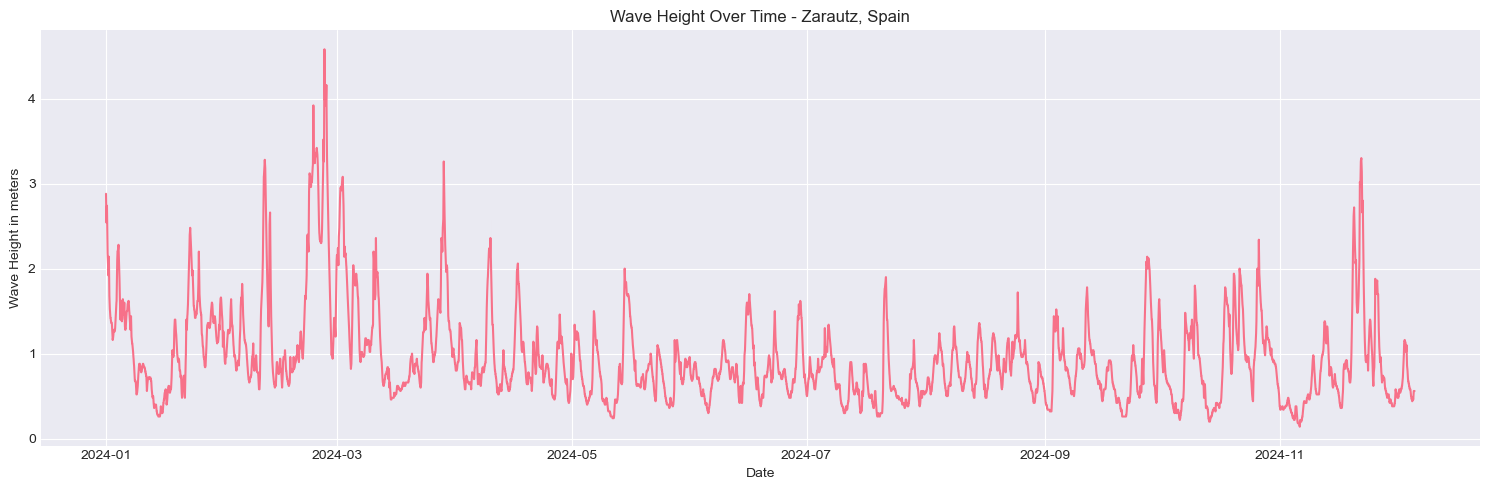

In [28]:
# Plot of wave height over the time
plt.figure(figsize=(15,5))
plt.plot(df['time'], df['wave_height'])
plt.title("Wave Height Over Time - Zarautz, Spain")
plt.xlabel("Date")
plt.ylabel("Wave Height in meters")
plt.grid(True)
plt.tight_layout()
plt.show()

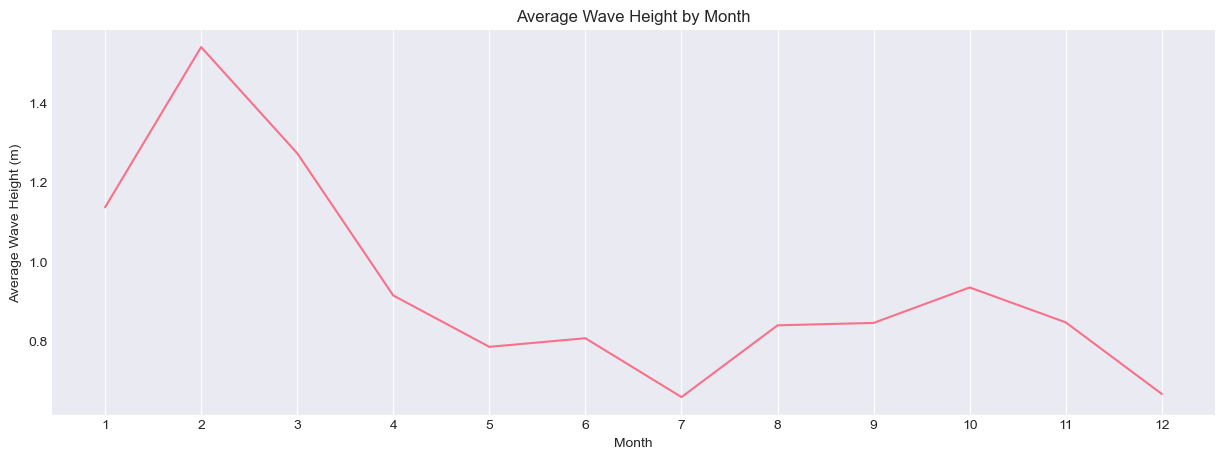

In [44]:
# Extract month from time
df['month'] = df['time'].dt.month

# Avarage wave height by month
monthly_avg = df.groupby('month')['wave_height'].mean()

# Plot
plt.figure(figsize=(15,5))
plt.plot(monthly_avg.index, monthly_avg.values)
plt.title('Average Wave Height by Month')
plt.xlabel('Month')
plt.ylabel('Average Wave Height (m)')
plt.xticks(range(1, 13))
plt.grid(axis='y')
plt.show()

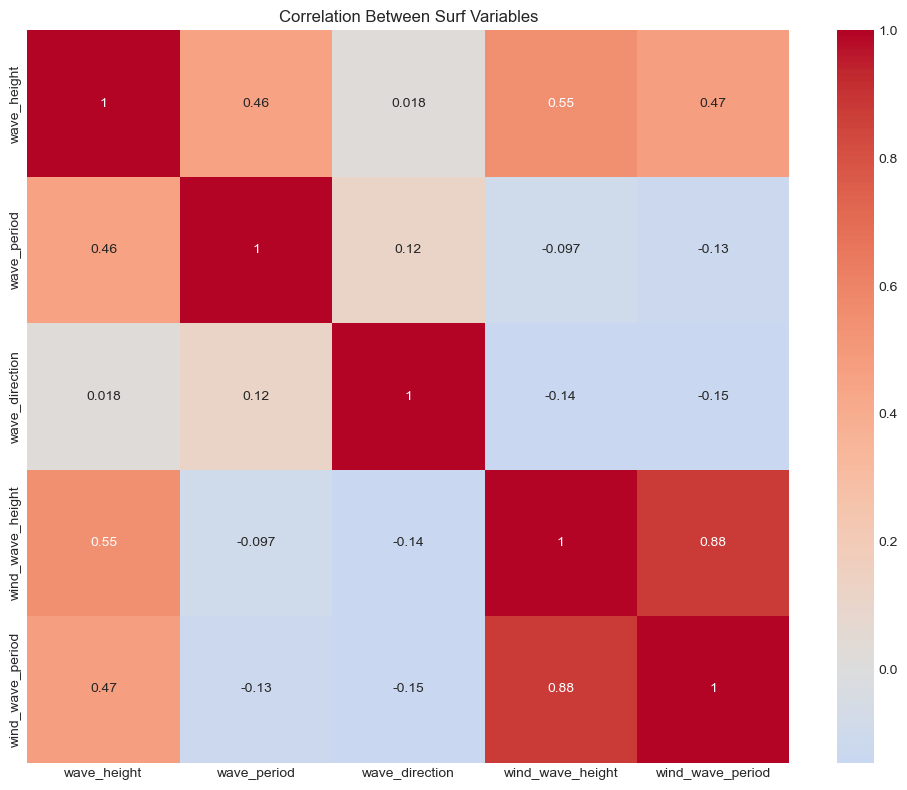

In [49]:
# Correlation Matrix
correlation = df[['wave_height', 'wave_period', 'wave_direction', 
                   'wind_wave_height', 'wind_wave_period']].corr()

# Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Between Surf Variables')
plt.tight_layout()
plt.show()

In [50]:
# Distribution of wave_height
print("Wave Height Statistics:")
print(df['wave_height'].describe())

print("\nWave Period Statistics:")
print(df['wave_period'].describe())

Wave Height Statistics:
count    8160.000000
mean        0.955532
std         0.554736
min         0.140000
25%         0.600000
50%         0.820000
75%         1.145000
max         4.580000
Name: wave_height, dtype: float64

Wave Period Statistics:
count    8160.000000
mean        8.740386
std         2.458899
min         3.150000
25%         6.950000
50%         8.350000
75%        10.300000
max        16.900000
Name: wave_period, dtype: float64


In [53]:
# Create target variable: Good (1) or Poor (0)
def classify_conditions(row):
    if (1.0 <= row['wave_height'] <= 2.5 and 
        row['wave_period'] > 7 and 
        row['wind_wave_height'] < 0.5):
        return 1  # Good
    else:
        return 0  # Poor

df['conditions'] = df.apply(classify_conditions, axis=1)

# Check distribution
print("Conditions distribution:")
print(df['conditions'].value_counts())
print(f"\nPercentage Good: {df['conditions'].mean() * 100:.1f}%")

Conditions distribution:
conditions
0    6199
1    1961
Name: count, dtype: int64

Percentage Good: 24.0%


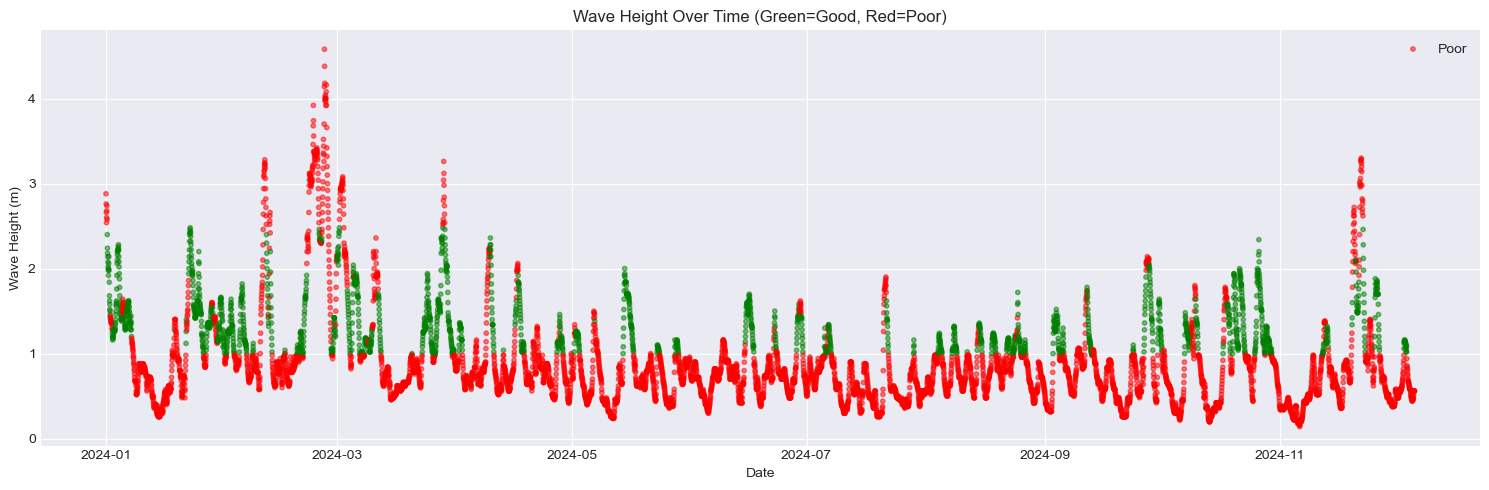

In [54]:
# Visualize good vs poor conditions over time
plt.figure(figsize=(15, 5))
colors = df['conditions'].map({0: 'red', 1: 'green'})
plt.scatter(df['time'], df['wave_height'], c=colors, alpha=0.5, s=10)
plt.title('Wave Height Over Time (Green=Good, Red=Poor)')
plt.xlabel('Date')
plt.ylabel('Wave Height (m)')
plt.legend(['Poor', 'Good'])
plt.grid(True)
plt.tight_layout()
plt.show()